<a href="https://colab.research.google.com/github/SludgeDanny/Probabilidad-y-Estad-stica/blob/main/Unidad6/U6_ProyetoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Probabilidad y Estadistica.
##Unidad 6.
##Proyecto Final.
##Grupo: 2YY.


###Maestro: José Gabriel Rodrigez Rivas.
###Alumnos:
### Daniel Rosales Reyes.
###Judith Azeneth Reyes Martínez.
###Erick Alexis Flores Reyes.

###Fecha de Entrega: 25 de Mayo de 2026.

# 1.Estadistca descritpiva
1.1 Numero de casos positivos, negativos, pendientes de resultado

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive', force_remount=True)

# Cargar el archivo CSV.
file_path = '/content/drive/MyDrive/covid2020-2021-codificado.csv'

# Check if the file exists before attempting to read it
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the file is in your Google Drive 'MyDrive' folder and the path/name is correct.")
    print("Listing contents of /content/drive/MyDrive/ for debugging:")
    !ls -l "/content/drive/MyDrive/"
else:
    try:
        df = pd.read_csv(file_path)

        # Mostrar información general del DataFrame y las primeras filas
        print("Información general del DataFrame:")
        df.info()
        print("\nPrimeras 5 filas del DataFrame:")
        display(df.head())

        # Mapear columnas numéricas a descripciones legibles si no lo están ya
        # TIPO_PACIENTE: 1=AMBULATORIO, 2=HOSPITALIZADO
        if 'TIPO_PACIENTE' in df.columns:
            df['TIPO_PACIENTE_DESC'] = df['TIPO_PACIENTE'].map({1: 'Ambulatorio', 2: 'Hospitalizado'})

        # CLASIFICACION_FINAL: 1=POSITIVO COVID, 2=NO POSITIVO COVID, 3=RESULTADO PENDIENTE
        if 'CLASIFICACION_FINAL' in df.columns:
            df['CLASIFICACION_FINAL_DESC'] = df['CLASIFICACION_FINAL'].map({
                1: 'POSITIVO COVID',
                2: 'NO POSITIVO COVID',
                3: 'RESULTADO PENDIENTE',
                4: 'INVÁLIDO',
                5: 'NO APLICA'
            })

        # EMBARAZO: 1=SI, 2=NO, 97=NO APLICA (en mujeres), 98=SE IGNORA, 99=NO ESPECIFICADO (en hombres)
        if 'EMBARAZO' in df.columns:
            df['EMBARAZO_DESC'] = df['EMBARAZO'].map({1: 'Sí', 2: 'No', 97: 'No Aplica (mujer)', 98: 'Se Ignora', 99: 'No Aplica (hombre)'})

        # INDIGENA: 1=SI, 2=NO, 99=NO ESPECIFICADO
        if 'INDIGENA' in df.columns:
            df['INDIGENA_DESC'] = df['INDIGENA'].map({1: 'Sí', 2: 'No', 99: 'No especificado'})

        # SEXO: 1=MUJER, 2=HOMBRE
        if 'SEXO' in df.columns:
            df['SEXO_DESC'] = df['SEXO'].map({1: 'Femenino', 2: 'Masculino'})

    except FileNotFoundError:
        print(f"An unexpected FileNotFoundError occurred even after checking: {file_path}")
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")

Mounted at /content/drive


/tmp/ipykernel_28468/3465884244.py:21: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12634194 entries, 0 to 12634193
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   SECTOR              object
 1   SEXO                object
 2   ENTIDAD_NAC         object
 3   TIPO_PACIENTE       object
 4   FECHA_INGRESO       object
 5   FECHA_DEF           object
 6   INTUBADO            object
 7   NEUMONIA            object
 8   EDAD                int64 
 9   EMBARAZO            object
 10  INDIGENA            object
 11  DIABETES            object
 12  EPOC                object
 13  ASMA                object
 14  HIPERTENSION        object
 15  CARDIOVASCULAR      object
 16  OBESIDAD            object
 17  RENAL_CRONICA       object
 18  TABAQUISMO          object
 19  RESULTADO_ANTIGENO  object
 20  UCI                 object
dtypes: int64(1), object(20)
memory usage: 2.0+ GB

Primeras 5 filas del DataFrame:


,SECTOR,SEXO,ENTIDAD_NAC,TIPO_PACIENTE,FECHA_INGRESO,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,EMBARAZO,...,DIABETES,EPOC,ASMA,HIPERTENSION,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,RESULTADO_ANTIGENO,UCI
0,Issste,Femenino,San Luis Potosí,Ambulatorio,2020-12-06,9999-99-99,No aplica,No,55,No,...,Si,No,No,No,No,No,No,No,Pendiente,No aplica
1,Issste,Masculino,San Luis Potosí,Ambulatorio,2020-02-20,9999-99-99,No aplica,No,59,No aplica,...,No,No,No,No,No,No,No,No,Pendiente,No aplica
2,Ssa,Femenino,Jalisco,Ambulatorio,2020-04-22,9999-99-99,No aplica,No,42,No,...,No,No,Si,No,No,No,No,No,Pendiente,No aplica
3,Ssa,Masculino,Chihuahua,Ambulatorio,2020-07-28,9999-99-99,No aplica,No,35,No aplica,...,No,No,No,No,No,No,No,No,Pendiente,No aplica
4,Ssa,Masculino,Ciudad De México,Ambulatorio,2020-08-18,9999-99-99,No aplica,No,51,No aplica,...,No,No,No,Si,No,No,No,No,Pendiente,No aplica


In [ ]:
print(f"Checking for file at: {file_path}")
!ls -l "/content/drive/MyDrive/"

Checking for file at: /content/drive/MyDrive/covid2020-2021-codificado.csv
total 1578456
-rw------- 1 root root        180 Dec  3 22:58 '3.Ejemplos de Referencias Bibliográficas APA.gdoc'
drwx------ 2 root root       4096 Nov 22 16:33  Audio
-rw------- 1 root root        180 Mar 21 02:29 'Ayuda para Estudiar Examen de Inglés.gsheet'
drwx------ 2 root root       4096 Feb 22 20:48  casa
drwx------ 2 root root       4096 Aug 29  2025  Classroom
drwx------ 2 root root       4096 Feb  4 18:33 'Colab Notebooks'
-rw------- 1 root root      24524 Mar  4 04:09 'Copia de guia temas 2-1 y 2-2.docx'
-rw------- 1 root root 1615310435 May 23 20:45  covid2020-2021-codificado.csv
drwx------ 2 root root       4096 Sep 15  2025 'Cuadro sinoptico'
drwx------ 2 root root       4096 Apr 27 00:10  Disgrama_UML
-rw------- 1 root root        180 Feb  6 05:35 'Documento sin título.gdoc'
-rw------- 1 root root     123467 Mar 18 00:30  Estructuras_moleculares.jpeg
-rw------- 1 root root        180 Nov 18  202

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1.Estadistca descritpiva
1.2 Numero de pacientes hospitalizados y ambulatorios

In [ ]:
# Número de pacientes hospitalizados y ambulatorios
if 'TIPO_PACIENTE' in df.columns:
    print("\nNúmero de pacientes por tipo:")
    display(df['TIPO_PACIENTE'].value_counts())
else:
    print("La columna 'TIPO_PACIENTE' no está disponible.")


Número de pacientes por tipo:


,count
TIPO_PACIENTE,
Ambulatorio,11543303
Hospitalizado,1090891


# 1.Estadistca descritpiva
1.3 Numero de pacientes que estan embarazadas

In [ ]:
print("\nValores únicos y conteos para la columna 'EMBARAZO':")
if 'EMBARAZO' in df.columns:
    display(df['EMBARAZO'].value_counts())
else:
    print("La columna 'EMBARAZO' no se encontró en el DataFrame.")


Valores únicos y conteos para la columna 'EMBARAZO':


,count
EMBARAZO,
No,6483614
No aplica,5985456
Si,122583
Se ignora,42529
No especificado,12


# 1.Estadistca descritpiva
1.4 Numero de personas que son indigenas

In [ ]:
print("\nValores únicos y conteos para la columna 'INDIGENA':")
if 'INDIGENA' in df.columns:
    display(df['INDIGENA'].value_counts())
else:
    print("La columna 'INDIGENA' no se encontró en el DataFrame.")


Valores únicos y conteos para la columna 'INDIGENA':


,count
INDIGENA,
No,3665974
No especificado,167182
Si,35240


# 1.Visualizacion
Grafico de barras horizontal por estado



/tmp/ipykernel_28468/3416518755.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')


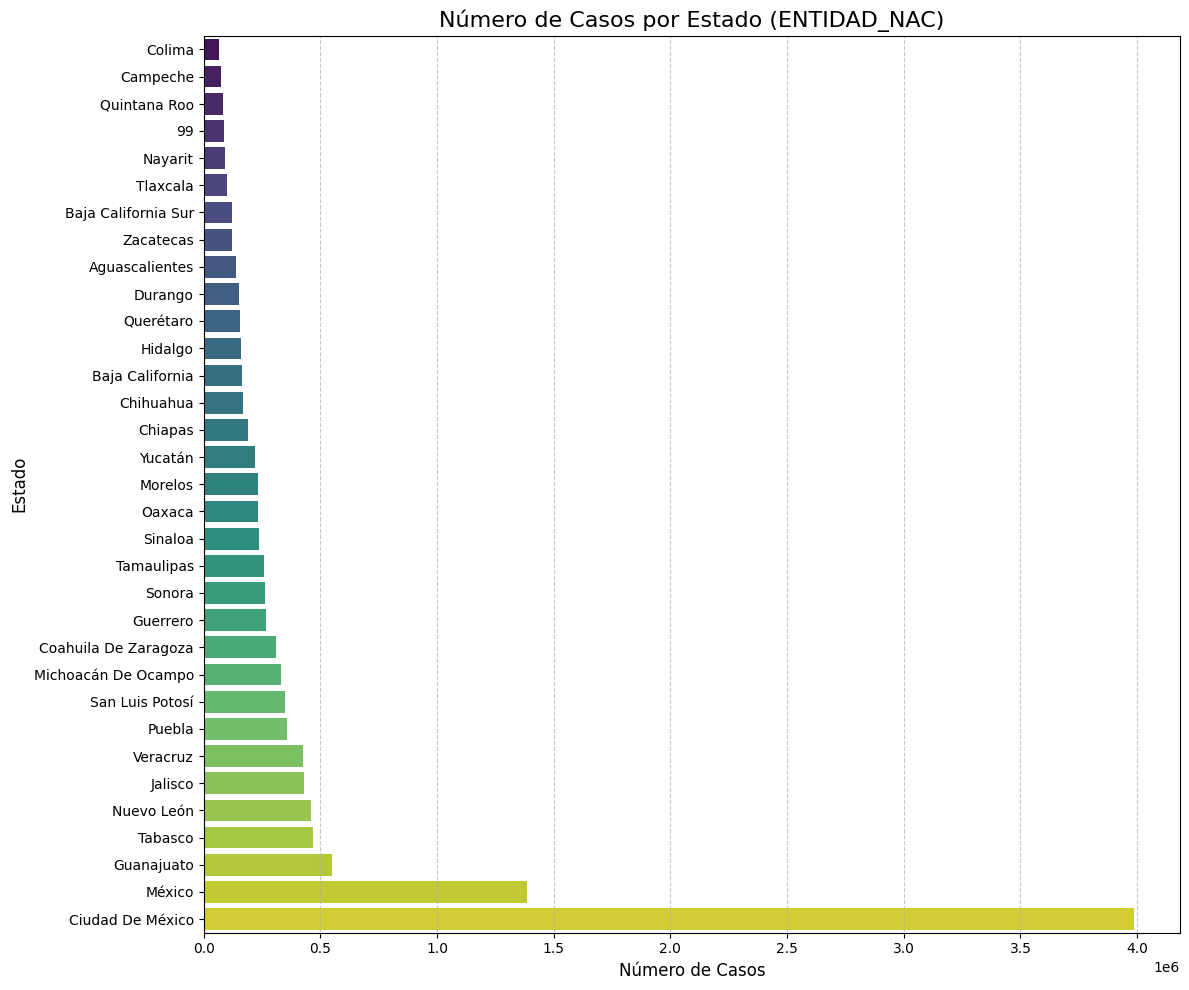

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Inicializar la variable para evitar NameError
col_entidad = None

# Buscar columna de entidad - Actualizado para incluir ENTIDAD_NAC
for col in ['ENTIDAD_NAC', 'ENTIDAD_UM', 'ENTIDAD_RES', 'ENTIDAD_FEDERATIVA', 'ESTADO']:
    if 'df' in locals() and col in df.columns:
        col_entidad = col
        break

if 'df' in locals() and col_entidad is not None:
    # Contar la frecuencia de cada estado
    state_counts = df[col_entidad].value_counts().sort_values(ascending=True)

    plt.figure(figsize=(12, 10))
    sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')
    plt.title(f'Número de Casos por Estado ({col_entidad})', fontsize=16)
    plt.xlabel('Número de Casos', fontsize=12)
    plt.ylabel('Estado', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"La columna de entidad no está disponible o el DataFrame no está cargado.")

# 1.Visualizacion
Histograma por edad

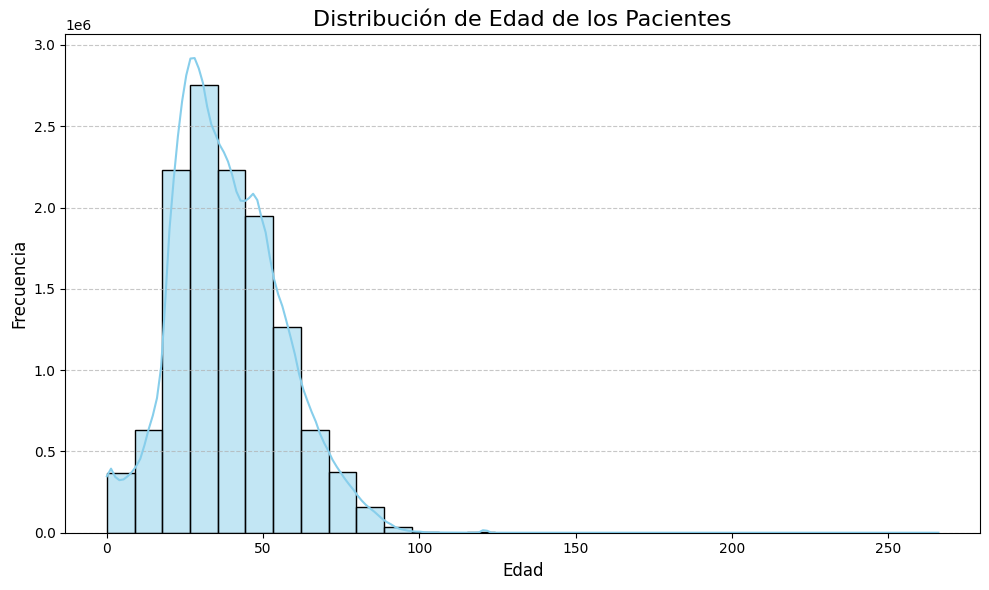

In [ ]:
if 'EDAD' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['EDAD'], bins=30, kde=True, color='skyblue')
    plt.title('Distribución de Edad de los Pacientes', fontsize=16)
    plt.xlabel('Edad', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("La columna 'EDAD' no está disponible para generar el histograma.")

# 1.Visualizacion
Gráfico de líneas por fecha para mostrar la evolución de casos.

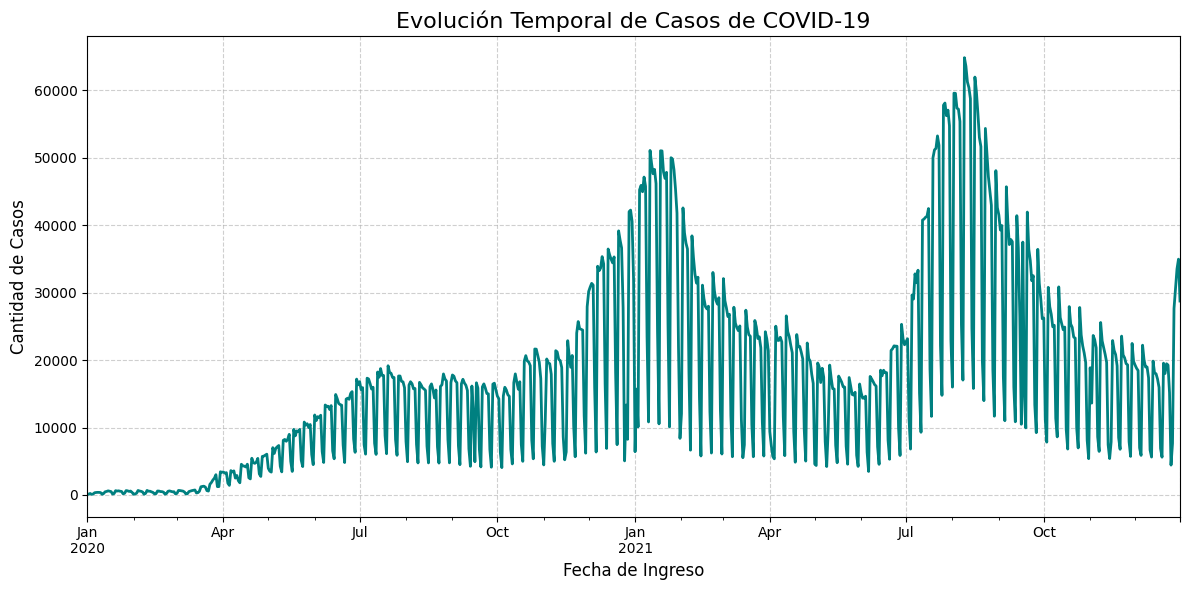

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Verificar que la columna de fecha existe
if 'FECHA_INGRESO' in df.columns:
    # Asegurar formato datetime
    df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'], errors='coerce')

    # Agrupar por fecha y contar casos
    casos_por_fecha = df.groupby('FECHA_INGRESO').size()

    # Crear el gráfico de líneas
    plt.figure(figsize=(12, 6))
    casos_por_fecha.plot(kind='line', color='teal', linewidth=2)

    plt.title('Evolución Temporal de Casos de COVID-19', fontsize=16)
    plt.xlabel('Fecha de Ingreso', fontsize=12)
    plt.ylabel('Cantidad de Casos', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró la columna 'FECHA_INGRESO' para realizar el seguimiento temporal.")

# 1.Visualizacion
Gráfico de barras apiladas por sexo y resultado.

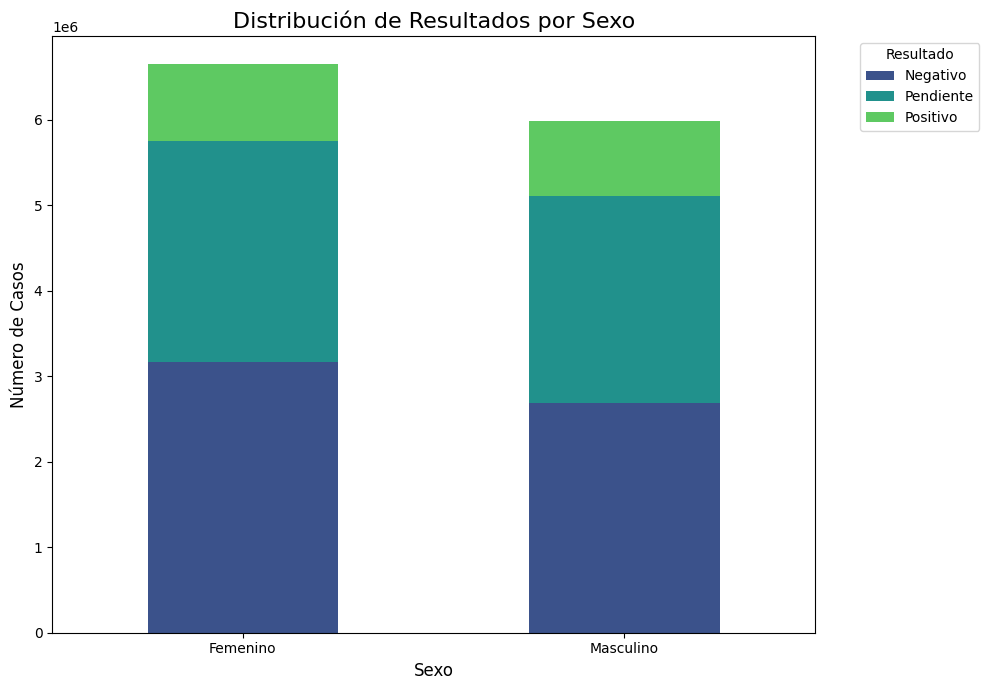

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'df' in locals():
    # Attempt to locate columns even if named slightly differently
    col_sexo = next((c for c in df.columns if 'SEXO' in c.upper()), None)
    col_clas = next((c for c in df.columns if 'CLASIFICACION_FINAL' in c.upper() or 'RESULTADO' in c.upper()), None)

    if col_sexo and col_clas:
        # 1. Prepare Sex Labels
        if df[col_sexo].dtype == object and ('Femenino' in df[col_sexo].values or 'Masculino' in df[col_sexo].values):
            df['SEXO_DESC'] = df[col_sexo]
        else:
            df['SEXO_DESC'] = df[col_sexo].astype(str).str.strip().map({'1': 'Femenino', '2': 'Masculino'})

        # 2. Prepare Classification Labels
        mapping = {
            '1': 'POSITIVO COVID',
            '2': 'NO POSITIVO COVID',
            '3': 'RESULTADO PENDIENTE',
            '4': 'INVÁLIDO',
            '5': 'NO APLICA',
            '6': 'CASO SOSPECHOSO',
            '7': 'NEGATIVO'
        }
        clas_str = df[col_clas].astype(str).str.strip()
        df['CLASIFICACION_FINAL_DESC'] = clas_str.map(mapping).fillna(df[col_clas])

        # 3. Plot
        if df['SEXO_DESC'].notnull().any():
            ct = pd.crosstab(df['SEXO_DESC'], df['CLASIFICACION_FINAL_DESC'])
            ct.plot(kind='bar', stacked=True, figsize=(10, 7), color=sns.color_palette('viridis', len(ct.columns)))

            plt.title('Distribución de Resultados por Sexo', fontsize=16)
            plt.xlabel('Sexo', fontsize=12)
            plt.ylabel('Número de Casos', fontsize=12)
            plt.legend(title='Resultado', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            print("No se pudieron mapear las descripciones legibles.")
    else:
        print(f"No se encontraron columnas de Sexo o Clasificación. Columnas disponibles: {list(df.columns)}")
else:
    print("El DataFrame 'df' no está cargado.")

# 1.Visualizacion
Gráfico circular por tipo de paciente

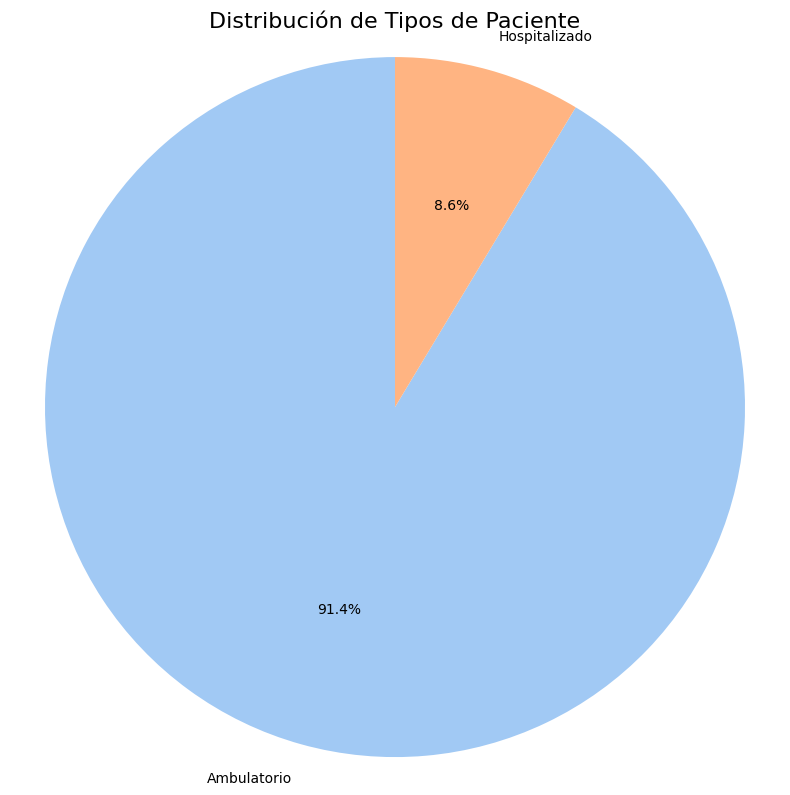

In [ ]:
# Asegurarse de que 'TIPO_PACIENTE' está disponible

if 'TIPO_PACIENTE' in df.columns:
    patient_type_counts = df['TIPO_PACIENTE'].value_counts()

    plt.figure(figsize=(8, 8))
    plt.pie(patient_type_counts, labels=patient_type_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.title('Distribución de Tipos de Paciente', fontsize=16)
    plt.axis('equal') # Asegura que el gráfico circular sea un círculo
    plt.tight_layout()
    plt.show()
else:
    print("La columna 'TIPO_PACIENTE' no está disponible para generar el gráfico circular.")

# 1.Visualizacion
Gráfico de barras por comorbilidad

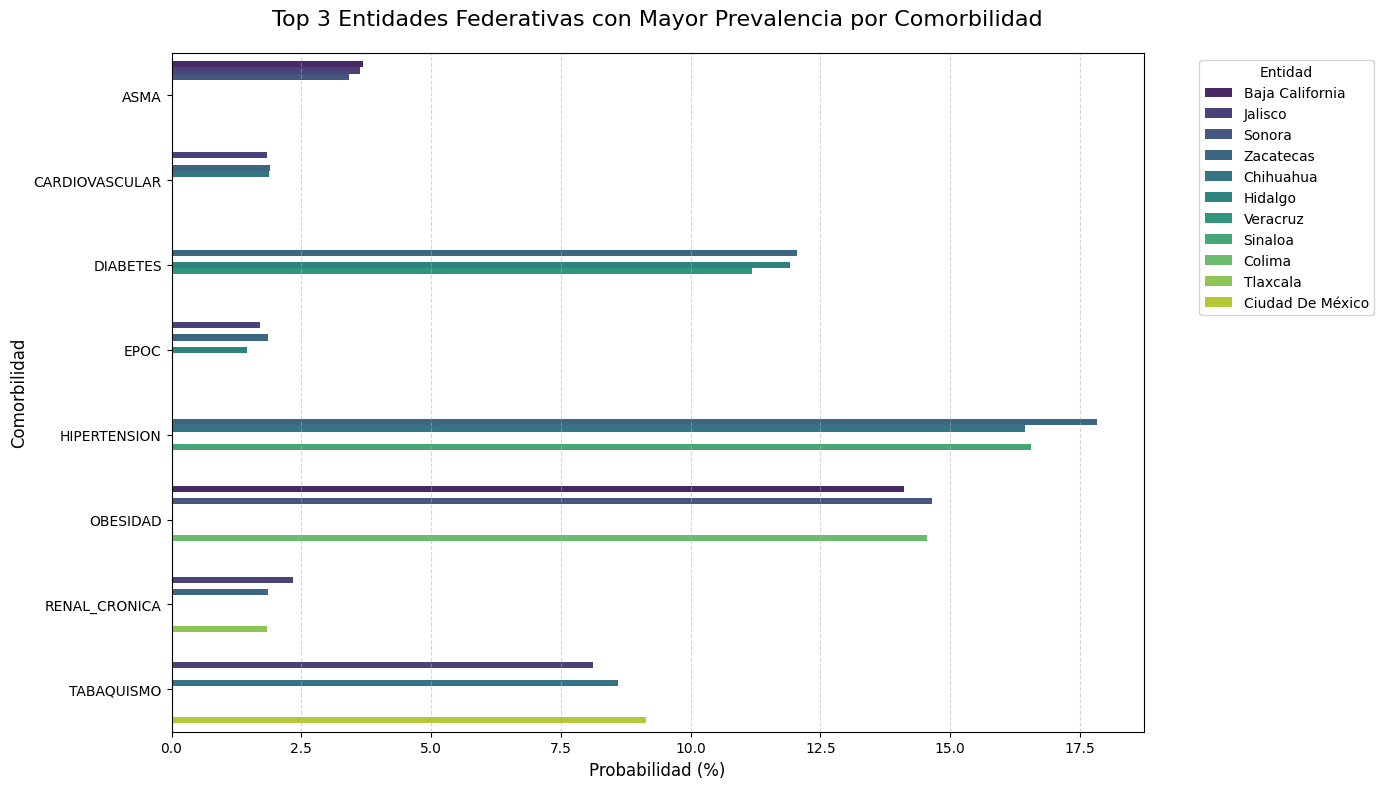

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Definir variables necesarias localmente
comorbilidades_list = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'EPOC', 'ASMA', 'RENAL_CRONICA', 'CARDIOVASCULAR', 'TABAQUISMO']
col_entidad_local = None

# Buscar columna de entidad
for col in ['ENTIDAD_NAC', 'ENTIDAD_UM', 'ENTIDAD_RES', 'ESTADO']:
    if 'df' in locals() and col in df.columns:
        col_entidad_local = col
        break

if 'df' in locals() and col_entidad_local:
    all_plot_data = []

    # Iterar sobre cada comorbilidad
    for comorb in comorbilidades_list:
        if comorb in df.columns:
            # Convertimos a numérico (1 para 'Si', 0 para otros) para promediar
            if df[comorb].dtype == 'object':
                temp_series = (df[comorb] == 'Si').astype(int)
            else:
                temp_series = (df[comorb] == 1).astype(int)

            # Calcular media por entidad y multiplicar por 100
            stats = temp_series.groupby(df[col_entidad_local]).mean() * 100

            for ent, prob in stats.items():
                all_plot_data.append({
                    'Entidad': ent,
                    'Comorbilidad': comorb,
                    'Probabilidad': prob
                })

    df_master_plot = pd.DataFrame(all_plot_data)

    # Obtener el Top 3 por cada comorbilidad asegurando que la columna 'Comorbilidad' permanezca
    top_by_comorb = df_master_plot.sort_values(['Comorbilidad', 'Probabilidad'], ascending=[True, False])
    top_by_comorb = top_by_comorb.groupby('Comorbilidad').head(3).reset_index(drop=True)

    # Configuración del gráfico
    plt.figure(figsize=(14, 8))
    sns.barplot(
        x='Probabilidad',
        y='Comorbilidad',
        hue='Entidad',
        data=top_by_comorb,
        palette='viridis'
    )

    plt.title('Top 3 Entidades Federativas con Mayor Prevalencia por Comorbilidad', fontsize=16, pad=20)
    plt.xlabel('Probabilidad (%)', fontsize=12)
    plt.ylabel('Comorbilidad', fontsize=12)
    plt.legend(title='Entidad', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Error: El DataFrame 'df' no está cargado o no se encontró una columna de Entidad.")

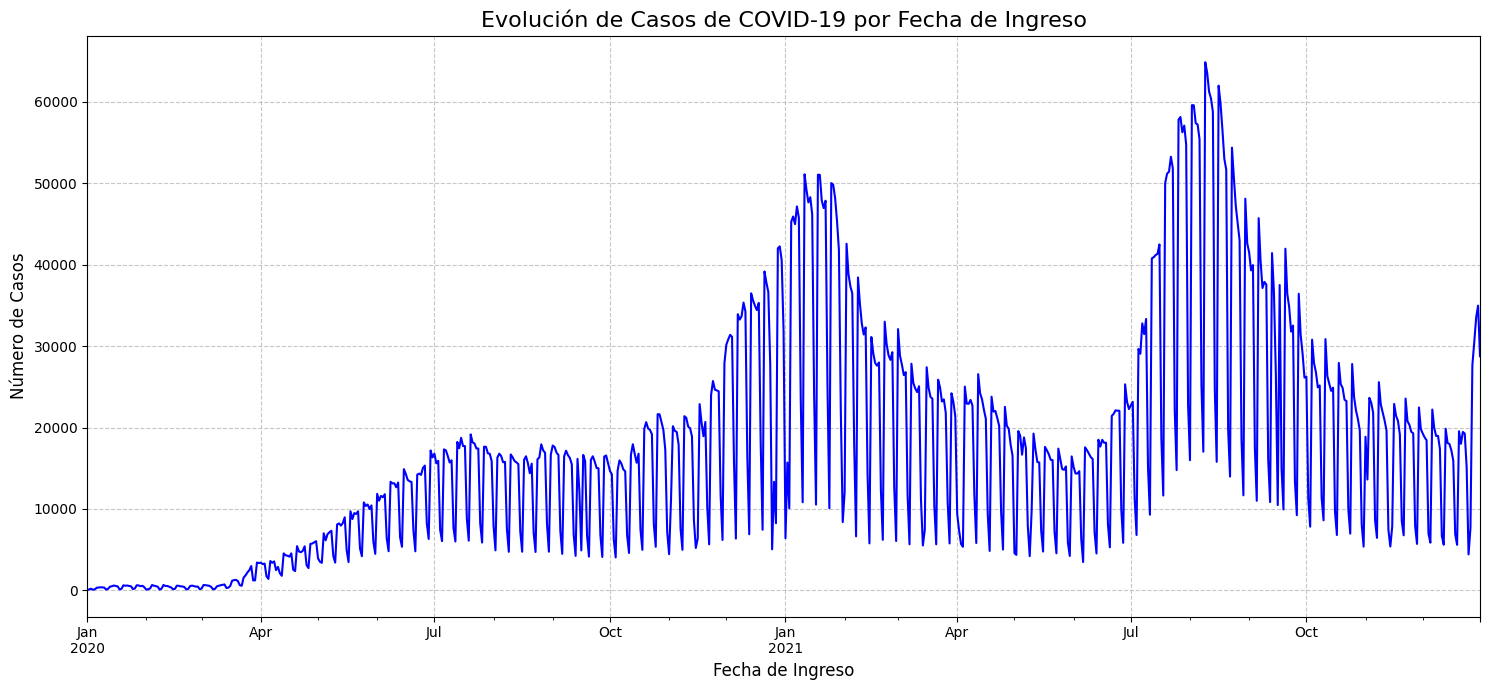

In [ ]:
# Asegurarse de que 'FECHA_INGRESO' es la columna de fecha y está en formato datetime

if 'FECHA_INGRESO' in df.columns:
    # Convertir a datetime si no lo está
    if not pd.api.types.is_datetime64_any_dtype(df['FECHA_INGRESO']):
        df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'], errors='coerce')

    # Eliminar filas con fechas nulas si las hubo en la conversión
    df_fecha = df.dropna(subset=['FECHA_INGRESO'])

    # Contar casos por fecha y ordenar por índice
    daily_cases = df_fecha['FECHA_INGRESO'].value_counts().sort_index()

    plt.figure(figsize=(15, 7))
    daily_cases.plot(kind='line', color='blue')
    plt.title('Evolución de Casos de COVID-19 por Fecha de Ingreso', fontsize=16)
    plt.xlabel('Fecha de Ingreso', fontsize=12)
    plt.ylabel('Número de Casos', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("La columna 'FECHA_INGRESO' no está disponible para generar el gráfico de líneas.")

#2. Probabilidades por Comorbilidad e Interpretación Estadística
2.1. Probabilidad simple.

In [ ]:
# Proporción de pacientes con cada comorbilidad en toda la base

# Total general de casos
total_general = len(df)
print(f"Total general de casos: {total_general:,}")

# Lista de comorbilidades
comorbilidades = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'EPOC', 'ASMA',
                  'INMUSUPR', 'RENAL_CRONICA', 'CARDIOVASCULAR', 'TABAQUISMO']

print("\n--- PROBABILIDAD SIMPLE ---")
for comorbilidad in comorbilidades:
    if comorbilidad in df.columns:
        # Contar pacientes con la comorbilidad (valor = 1 o "Si")
        if df[comorbilidad].dtype == 'object':
            total_comorbilidad = (df[comorbilidad] == 'Si').sum()
        else:
            total_comorbilidad = (df[comorbilidad] == 1).sum()

        # Calcular probabilidad
        probabilidad = (total_comorbilidad / total_general) * 100

        print(f"{comorbilidad}: {total_comorbilidad:,} pacientes - Probabilidad: {probabilidad:.2f}%")
    else:
        print(f"{comorbilidad}: Columna no encontrada en la base de datos")

Total general de casos: 12,634,194

--- PROBABILIDAD SIMPLE ---
DIABETES: 1,038,459 pacientes - Probabilidad: 8.22%
HIPERTENSION: 1,407,779 pacientes - Probabilidad: 11.14%
OBESIDAD: 1,193,021 pacientes - Probabilidad: 9.44%
EPOC: 92,446 pacientes - Probabilidad: 0.73%
ASMA: 263,855 pacientes - Probabilidad: 2.09%
INMUSUPR: Columna no encontrada en la base de datos
RENAL_CRONICA: 129,874 pacientes - Probabilidad: 1.03%
CARDIOVASCULAR: 134,410 pacientes - Probabilidad: 1.06%
TABAQUISMO: 865,162 pacientes - Probabilidad: 6.85%


#2. Probabilidades por Comorbilidad e Interpretación Estadística
2.1. Probabilidad condicional.

In [ ]:
# Buscar columna de entidad
col_entidad = None
# Se agrega ENTIDAD_NAC a la lista de búsqueda
for col in ['ENTIDAD_NAC', 'ENTIDAD_UM', 'ENTIDAD_RES', 'ENTIDAD_FEDERATIVA', 'ESTADO']:
    if col in df.columns:
        col_entidad = col
        break

if col_entidad:
    print(f"\n--- PROBABILIDAD CONDICIONAL POR ENTIDAD ---")
    print(f"Columna usada: {col_entidad}\n")

    # Para cada comorbilidad
    for comorbilidad in comorbilidades:
        if comorbilidad in df.columns:
            print(f"\n{comorbilidad}:")

            # Para cada entidad
            # Usamos unique() y ordenamos para una mejor visualización
            entidades = sorted(df[col_entidad].dropna().unique())
            for entidad in entidades:
                # Filtrar datos de esa entidad
                datos_entidad = df[df[col_entidad] == entidad]
                total_entidad = len(datos_entidad)

                if total_entidad > 0:
                    # Contar casos con comorbilidad
                    if df[comorbilidad].dtype == 'object':
                        casos = (datos_entidad[comorbilidad] == 'Si').sum()
                    else:
                        casos = (datos_entidad[comorbilidad] == 1).sum()

                    # Probabilidad condicional
                    prob = (casos / total_entidad) * 100
                    print(f"  {entidad}: {prob:.2f}%")
else:
    print("No se encontró columna de entidad. Las columnas disponibles son:", list(df.columns))


--- PROBABILIDAD CONDICIONAL POR ENTIDAD ---
Columna usada: ENTIDAD_NAC


DIABETES:
  99: 2.43%
  Aguascalientes: 7.57%
  Baja California: 8.50%
  Baja California Sur: 7.18%
  Campeche: 8.79%
  Chiapas: 8.24%
  Chihuahua: 10.56%
  Ciudad De México: 6.51%
  Coahuila De Zaragoza: 9.46%
  Colima: 8.02%
  Durango: 9.12%
  Guanajuato: 9.27%
  Guerrero: 10.57%
  Hidalgo: 11.92%
  Jalisco: 10.82%
  Michoacán De Ocampo: 9.03%
  Morelos: 7.27%
  México: 6.68%
  Nayarit: 9.55%
  Nuevo León: 9.18%
  Oaxaca: 9.86%
  Puebla: 10.74%
  Querétaro: 8.38%
  Quintana Roo: 4.52%
  San Luis Potosí: 9.68%
  Sinaloa: 10.10%
  Sonora: 9.56%
  Tabasco: 9.04%
  Tamaulipas: 11.04%
  Tlaxcala: 9.76%
  Veracruz: 11.19%
  Yucatán: 7.39%
  Zacatecas: 12.05%

HIPERTENSION:
  99: 5.11%
  Aguascalientes: 11.67%
  Baja California: 14.26%
  Baja California Sur: 11.07%
  Campeche: 12.49%
  Chiapas: 10.86%
  Chihuahua: 16.45%
  Ciudad De México: 8.69%
  Coahuila De Zaragoza: 12.55%
  Colima: 11.24%
  Durango: 13.27%
  Gua

#2. Probabilidades por Comorbilidad e Interpretación Estadística
2.3. Visualización (Gráfico de barras).

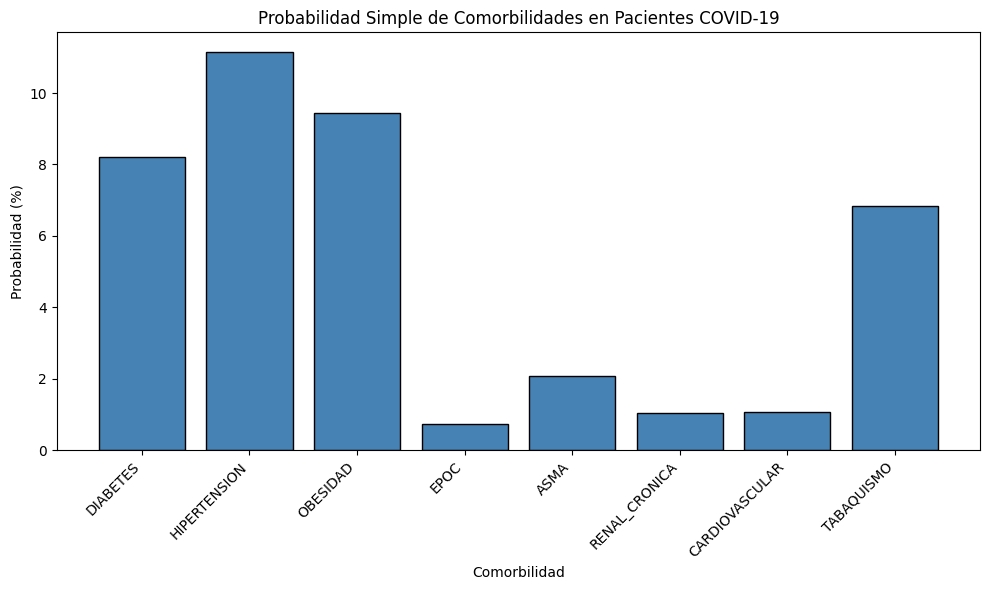

In [ ]:
import matplotlib.pyplot as plt

# Recolectar datos
nombres = []
probabilidades = []

for comorbilidad in comorbilidades:
    if comorbilidad in df.columns:
        if df[comorbilidad].dtype == 'object':
            total = (df[comorbilidad] == 'Si').sum()
        else:
            total = (df[comorbilidad] == 1).sum()

        prob = (total / total_general) * 100
        nombres.append(comorbilidad)
        probabilidades.append(prob)

# Crear gráfico
plt.figure(figsize=(10, 6))
plt.bar(nombres, probabilidades, color='steelblue', edgecolor='black')
plt.xlabel('Comorbilidad')
plt.ylabel('Probabilidad (%)')
plt.title('Probabilidad Simple de Comorbilidades en Pacientes COVID-19')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Ejercicio de distribución normal

En un análisis de casos positivos de COVID por estado, se observa que el número de
casos sigue una distribución normal con:

• Media: 2360 casos

• Desviación estándar: 714 casos

**Pregunta:** ¿Cuál es la probabilidad de que un estado tenga entre 2000 y 3000 casos
positivos?


In [ ]:
from scipy.stats import norm

# Definir parámetros
media = 2360
desv_est = 714
limite_inferior = 2000
limite_superior = 3000

# Calcular la probabilidad usando la función de distribución acumulada (CDF)
# P(2000 < X < 3000) = P(X < 3000) - P(X < 2000)
probabilidad = norm.cdf(limite_superior, media, desv_est) - norm.cdf(limite_inferior, media, desv_est)

print(f"La probabilidad de que un estado tenga entre {limite_inferior} y {limite_superior} casos es:")
print(f"{probabilidad:.4f} o {probabilidad*100:.2f}%")

La probabilidad de que un estado tenga entre 2000 y 3000 casos es:
0.5079 o 50.79%



# Interpretación General de Resultados



***1.*** La gran mayoría de los pacientes registrados fueron atendidos de forma **ambulatoria** (aproximadamente el 91.4%), lo que indica que la saturación hospitalaria, aunque crítica, representó una fracción menor del total de contagios registrados.

La distribución por **sexo** muestra una ligera prevalencia de casos registrados en mujeres, aunque la distribución de resultados positivos se mantiene equitativa entre ambos géneros.

***2.*** **Impacto de Comorbilidades:**
Las comorbilidades con mayor prevalencia en la población afectada fueron la **Hipertensión (11.14%)**, la **Obesidad (9.44%)** y la **Diabetes (8.22%)**. Estas condiciones presentan una correlación significativa con la vulnerabilidad ante el virus.

Esto nos permite identificar regiones geográficas donde la población es estadísticamente más propensa a presentar cuadros clínicos complejos debido a estas condiciones preexistentes.

***3.*** **Distribución Normal**
Mediante el ejercicio de distribución normal, determinamos que existe una probabilidad del **50.79%** de que un estado seleccionado al azar presente entre 2000 y 3000 casos positivos.

***4***.**Evolución Temporal:**
Las gráficas de líneas muestran picos claros de contagio que coinciden con la ola de contagios del COVID-19 observadas en México durante el periodo 2020-2021, permitiendo visualizar la el impacto de las medidas de movilidad en el tiempo.

# Conclusiones Personales

**Erick Alexis Flores Reyes**: Siento que con el uso de las herramientras de programación, en este caso siendo PYTHON facilita el analizis estadistico ya que con el uso de las funcionalidades que nos brinda este lenguaje de programacion como por ejemplo los pandas, nos genera de manera rapida y eficaz todo tipo de análisis de datos estructurados, facilitando el manejo de datos incluso si son excesivamente grandes.


**Judith Azeneth Reyes Martínez**: Considero que Python es una herramienta fundamental para el análisis estadístico moderno. Sus librerías, especialmente Pandas, permiten trabajar con datos estructurados de manera ágil y eficaz, simplificando tareas complejas t reduciendo tiempos de procesamiento, incluso con conjuntos de datos grandes. Esto mejora en gran manera la productividad y la calidad de análisis.

**Daniel Rosales Reyes**: Para ser sincero no creí aprender mucho por el hecho de que fue estadistica con codigo de Python pero me dió una perspectiva diferente de la materia, una en la que no solo eran numeros aurridos y cuentas largas, el uso de Python no solo hizo la materia más llevadera tambien me ayudó a comprender la probabilidad y estadistica de una manera diferente, más optima, rapida y sobretodo entretenida, pude aprender cosas que considero que en el papel me hubieran resultado complicadicimas y me hubiera resignado a aprender, para mi fue una buena experiencia el usar Python como metodo de aprendisaje.